In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import AgglomerativeClustering
from mpl_toolkits.mplot3d import Axes3D


# EDA

In [2]:
train_df = pd.read_csv(r'loans_train.csv')
if "index" in train_df.columns:
    train_df = train_df.drop(columns=["index"])
train_df.head()

,target,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,...,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity
0,0,747,202403,N,205402,NaN,0,1,P,67,...,202502,348,81190.87,8.000,0.0,999,81190.87,13,202503,347
1,0,659,202403,N,205402,NaN,0,1,P,68,...,202502,348,301932.72,7.875,0.0,64,301932.72,13,202503,347
2,0,775,202403,N,205402,46540.0,0,2,I,70,...,202502,348,152044.42,7.625,0.0,999,152044.42,13,202503,347
3,0,815,202403,Y,205402,NaN,25,1,P,88,...,202502,348,50045.91,7.250,0.0,70,50045.91,13,202503,347
4,0,772,202403,N,205402,10900.0,0,1,P,69,...,202502,348,153521.39,7.750,0.0,63,153521.39,13,202503,347


In [3]:
test_df = pd.read_csv(r'loans_test.csv',index_col=0)
test_df.head()

,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,OriginalDTI,...,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity
Id,,,,,,,,,,,,,,,,,,,,,
0,773,202403,N,205402,10580.0,0,1,I,80,20,...,202502,348,172694.72,7.624,0.0,61,172694.72,13,202503,347
1,801,202403,Y,205402,24860.0,30,1,P,95,40,...,202502,348,310033.21,6.990,0.0,87,310033.21,13,202503,347
2,777,202403,N,205402,27260.0,0,1,P,45,41,...,202502,348,490992.62,6.625,0.0,42,490992.62,13,202503,347
3,816,202403,N,205402,38900.0,25,1,P,87,35,...,202502,348,577698.55,6.500,0.0,81,577698.55,13,202503,347
4,731,202403,N,205402,48680.0,0,1,P,80,47,...,202502,348,203672.30,7.375,0.0,71,203672.30,13,202503,347


In [4]:
test_df

,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,OriginalDTI,...,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity
Id,,,,,,,,,,,,,,,,,,,,,
0,773,202403,N,205402,10580.0,0,1,I,80,20,...,202502,348,172694.72,7.624,0.0,61,172694.72,13,202503,347
1,801,202403,Y,205402,24860.0,30,1,P,95,40,...,202502,348,310033.21,6.990,0.0,87,310033.21,13,202503,347
2,777,202403,N,205402,27260.0,0,1,P,45,41,...,202502,348,490992.62,6.625,0.0,42,490992.62,13,202503,347
3,816,202403,N,205402,38900.0,25,1,P,87,35,...,202502,348,577698.55,6.500,0.0,81,577698.55,13,202503,347
4,731,202403,N,205402,48680.0,0,1,P,80,47,...,202502,348,203672.30,7.375,0.0,71,203672.30,13,202503,347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13421,726,202403,N,205402,16984.0,30,1,P,95,49,...,202502,348,295701.72,6.625,0.0,90,295701.72,13,202503,347
13422,810,202403,N,205402,26420.0,0,1,P,66,24,...,202502,348,139881.87,5.964,0.0,59,139881.87,13,202503,347
13423,640,202403,Y,205402,38300.0,35,1,P,97,29,...,202502,348,129469.59,6.875,0.0,81,129469.59,13,202503,347


In [5]:
val_df = pd.read_csv(r'loans_valid.csv')
if "index" in val_df.columns:
    val_df = val_df.drop(columns=["index"])
val_df.head()

,target,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,...,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity
0,0,784,202403,N,205402,46540.0,0,1,P,76,...,202502,348,123552.68,6.750,0.0,69,123552.68,13,202503,347
1,0,786,202403,N,205402,15764.0,25,1,P,90,...,202502,348,605030.78,7.000,0.0,71,605030.78,13,202503,347
2,0,739,202403,N,205402,36540.0,0,1,P,23,...,202502,348,158234.13,7.000,0.0,21,158234.13,13,202503,347
3,0,773,202403,N,205402,NaN,0,1,P,65,...,202502,348,155843.09,6.875,0.0,58,155843.09,13,202503,347
4,0,736,202403,Y,205402,NaN,25,1,P,97,...,202502,348,66226.11,7.250,0.0,88,66226.11,13,202503,347


In [6]:
def show_missing_report(df):
    missing_report = (
        df.isnull().sum()
        .to_frame(name="MissingCount")
        .assign(MissingPct=lambda x: x["MissingCount"] / len(df) * 100)
        .query("MissingCount > 0")
        .sort_values(by="MissingPct", ascending=False)
    )
    return missing_report

In [7]:
print('Train:')
print(show_missing_report(train_df))
print('\nTest:')
print(show_missing_report(test_df))
print('\nVal:')
print(show_missing_report(val_df))

Train:
                          MissingCount  MissingPct
ReliefRefinanceIndicator         30504  100.000000
PreHARP_Flag                     30504  100.000000
SuperConformingFlag              30176   98.924731
MSA                               3422   11.218201

Test:
                          MissingCount  MissingPct
ReliefRefinanceIndicator         13426  100.000000
PreHARP_Flag                     13426  100.000000
SuperConformingFlag              13302   99.076419
MSA                               1529   11.388351

Val:
                          MissingCount  MissingPct
ReliefRefinanceIndicator          5370  100.000000
PreHARP_Flag                      5370  100.000000
SuperConformingFlag               5326   99.180633
MSA                                632   11.769088


In [8]:
def preprocessing(data):
    df = data.copy()
    df = df.drop(columns=['PreHARP_Flag'])
    df['MSA'] = df['MSA'].fillna(0)
    # Default day is first of the month
    # Convert yyyymm integer to string first
    df['FirstPaymentDate'] = df['FirstPaymentDate'].astype(str)
    df['MaturityDate'] = df['MaturityDate'].astype(str)

    # Convert to datetime: assume day = 1
    df['FirstPaymentDate'] = pd.to_datetime(df['FirstPaymentDate'], format='%Y%m')
    df['MaturityDate'] = pd.to_datetime(df['MaturityDate'], format='%Y%m')

    # Extract Year & Month
    df['FirstPaymentYear'] = df['FirstPaymentDate'].dt.year
    df['FirstPaymentMonth'] = df['FirstPaymentDate'].dt.month
    df['MaturityYear'] = df['MaturityDate'].dt.year
    df['MaturityMonth'] = df['MaturityDate'].dt.month

    # Loan Age in months (from first payment to today)
    df['LoanAge'] = ((pd.to_datetime('today') - df['FirstPaymentDate']).dt.days // 30).clip(lower=0)

    # Time to Maturity in months (from today to maturity)
    df['TimeToMaturity'] = ((df['MaturityDate'] - pd.to_datetime('today')).dt.days // 30).clip(lower=0)

    df['FirstTimeHomebuyerFlag'] = df['FirstTimeHomebuyerFlag'].map({'Y':1, 'N':0})
    df['SuperConformingFlag'] = df['SuperConformingFlag'].map({'Y': 1, np.nan: 0})
    df['InterestOnlyFlag'] = df['InterestOnlyFlag'].map({'Y': 1, 'N': 0})
    df['ReliefRefinanceIndicator'] = df['ReliefRefinanceIndicator'].map({'Y': 1, np.nan: 0})

    df = df[df['CreditScore'] < 9999]

    return df


def summary_stats_user(data):
    df = data.copy()
    """
    Compute summary features for loan repayment behavior.
    
    Assumptions:
    - OriginalUPB is the original loan balance
    - Columns like '0_CurrentActualUPB', '1_CurrentActualUPB', ... exist
    - Lateness needs to be derived (example: on-time if scheduled balance decrease > 0)
    """

    # Extract monthly UPB columns
    upb_cols = [c for c in df.columns if "_CurrentActualUPB" in c]
    upb_cols_sorted = sorted(upb_cols, key=lambda x: int(x.split("_")[0]))
    
    # Calculate repayment ratio per month = 1 - (UPB_t / OriginalUPB)
    repayment_ratios = df[upb_cols_sorted].apply(lambda row: 1 - row / row.name, axis=1)

    # But row.name is index, fix: we'll divide by OriginalUPB
    repayment_ratios = df[upb_cols_sorted].div(df["OriginalUPB"], axis=0)
    repayment_ratios = 1 - repayment_ratios

    # 1. Average repayment ratio
    df["avg_repayment_ratio"] = repayment_ratios.mean(axis=1)

    # 2. Std deviation of repayment ratio
    df["std_repayment_ratio"] = repayment_ratios.std(axis=1)

    # 3. % months late (example heuristic: repayment ratio in month <= previous month → late/no progress)
    is_late = repayment_ratios.diff(axis=1) <= 0
    df["pct_months_late"] = is_late.sum(axis=1) / len(upb_cols_sorted)

    # 4. Trend slope (fit linear regression of repayment ratio over months)
    months = np.arange(len(upb_cols_sorted)).reshape(-1, 1)
    slopes = []
    for i in range(len(df)):
        y = repayment_ratios.iloc[i].values
        model = LinearRegression().fit(months, y)
        slopes.append(model.coef_[0])
    df["repayment_trend_slope"] = slopes

    return df

def feature_engineering(data):
    df = data.copy()
    # =============================================================================
    # 1. RISK ASSESSMENT FEATURES
    # =============================================================================

    # Debt Service Ratio - actual monthly debt burden considering interest rates
    df['DebtServiceRatio'] = df['OriginalDTI'] * df['OriginalInterestRate'] / 100

    # LTV-DTI Interaction - combined leverage and debt risk
    df['LTV_DTI_Interaction'] = df['OriginalLTV'] * df['OriginalDTI']

    # Credit quality relative to leverage and debt
    df['CreditScore_LTV_Ratio'] = df['CreditScore'] / df['OriginalLTV']
    df['CreditScore_DTI_Ratio'] = df['CreditScore'] / (df['OriginalDTI'] + 1e-6)

    # Risk categories
    df['HighRiskCredit'] = (df['CreditScore'] < 620).astype(int)
    df['HighLTV'] = (df['OriginalLTV'] > 80).astype(int)
    df['HighDTI'] = (df['OriginalDTI'] > 43).astype(int)
    df['HighInterestRate'] = (df['OriginalInterestRate'] > df['OriginalInterestRate'].quantile(0.75)).astype(int)

    # Combined risk score
    df['CompositeRiskScore'] = (df['HighRiskCredit'] + 
                                        df['HighLTV'] + 
                                        df['HighDTI'] + 
                                        df['HighInterestRate'])

    df = summary_stats_user(df)
    return df

In [9]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(30504, 144)
(5370, 144)
(13426, 143)


In [10]:
train_df_clean = preprocessing(train_df)
val_df_clean = preprocessing(val_df)
test_df_clean = preprocessing(test_df)
print(train_df_clean.shape)
print(val_df_clean.shape)
print(test_df_clean.shape)

(30496, 149)
(5370, 149)
(13423, 148)


In [11]:
train_df_fe = feature_engineering(train_df_clean)
val_df_fe = feature_engineering(val_df_clean)
test_df_fe = feature_engineering(test_df_clean)
print(train_df_fe.shape)
print(val_df_fe.shape)
print(test_df_fe.shape)

(30496, 162)
(5370, 162)
(13423, 161)


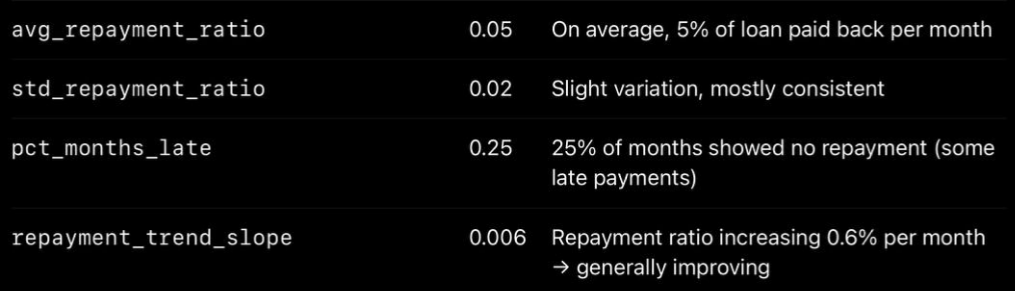

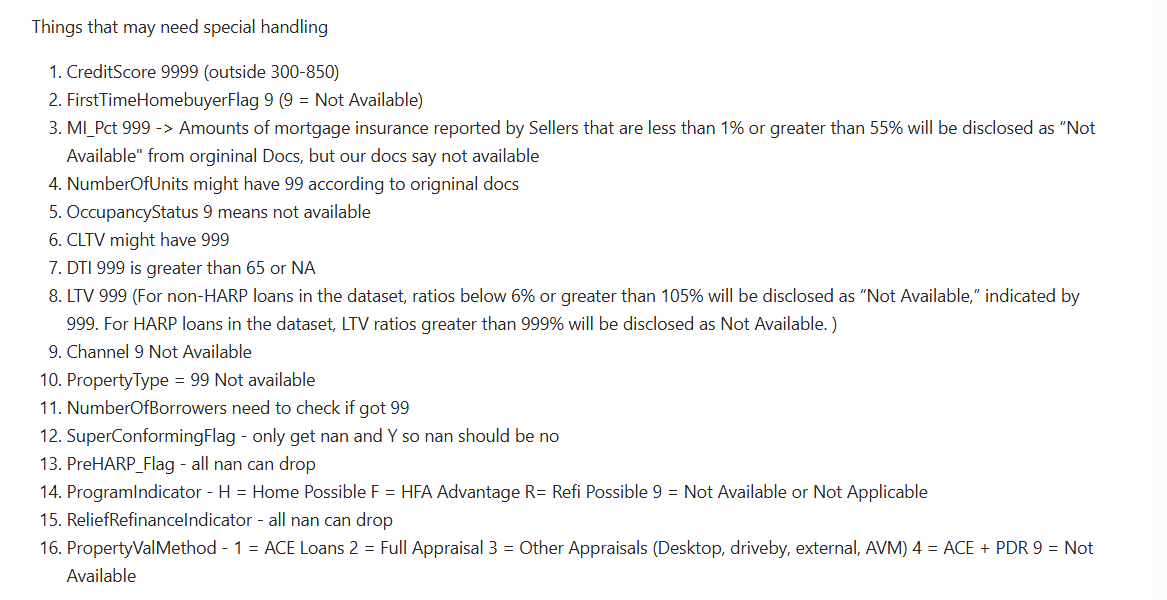

# Encoding Categorical Features

In [12]:
def encode_df(data):
    df = data.copy()
    #Get list of categorical variables
    s = (df.dtypes == 'object')
    object_cols = list(s[s].index)

    print("Categorical variables in the dataset:", object_cols)
    #Label Encoding the object dtypes
    LE=LabelEncoder()
    for i in object_cols:
        df[i]=df[[i]].apply(LE.fit_transform)
    return df

In [13]:
train_df_encoded = encode_df(train_df_fe)
val_df_encoded = encode_df(val_df_fe)
test_df_encoded = encode_df(test_df_fe)

Categorical variables in the dataset: ['OccupancyStatus', 'Channel', 'PPM_Flag', 'ProductType', 'PropertyState', 'PropertyType', 'LoanPurpose', 'SellerName', 'ServicerName', 'ProgramIndicator', 'BalloonIndicator']
Categorical variables in the dataset: ['OccupancyStatus', 'Channel', 'PPM_Flag', 'ProductType', 'PropertyState', 'PropertyType', 'LoanPurpose', 'SellerName', 'ServicerName', 'ProgramIndicator', 'BalloonIndicator']
Categorical variables in the dataset: ['OccupancyStatus', 'Channel', 'PPM_Flag', 'ProductType', 'PropertyState', 'PropertyType', 'LoanPurpose', 'SellerName', 'ServicerName', 'ProgramIndicator', 'BalloonIndicator']


# Clustering

In [14]:
col_to_use  =[
    "CreditScore",
    "OriginalDTI",
    "OriginalLTV",
    "OriginalCLTV",
    "OriginalInterestRate",
    "NumberOfBorrowers",
    "LoanPurpose",
    "PropertyState",
    "PropertyType",
    "Channel",
    "CompositeRiskScore",
    "avg_repayment_ratio",
    "std_repayment_ratio",
    "pct_months_late",
    "repayment_trend_slope",
    "DebtServiceRatio",
    "LoanAge",
    "TimeToMaturity",
    '0_CurrentActualUPB',
    '1_CurrentActualUPB',
    '2_CurrentActualUPB',
    '3_CurrentActualUPB',
    '4_CurrentActualUPB',
    '5_CurrentActualUPB',
    '6_CurrentActualUPB',
    '7_CurrentActualUPB',
    '8_CurrentActualUPB',
    '9_CurrentActualUPB',
    '10_CurrentActualUPB',
    '11_CurrentActualUPB',
    '12_CurrentActualUPB',
    '13_CurrentActualUPB']

In [15]:
def scale_features(data,col_to_use):
    ds = data.copy()
    # # creating a subset of dataframe by dropping the features on deals accepted and promotions
    # cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
    # ds = ds.drop(cols_del, axis=1)
    ds = ds[col_to_use]
    #Scaling
    scaler = StandardScaler()
    scaler.fit(ds)
    scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )
    print("All features are now scaled")
    return scaled_ds

In [16]:
train_df_scaled = scale_features(train_df_encoded,col_to_use)
val_df_scaled = scale_features(val_df_encoded,col_to_use)
test_df_scaled = scale_features(test_df_encoded,col_to_use)

All features are now scaled
All features are now scaled
All features are now scaled


In [17]:
def pca_3d(scaled_ds):
    # Perform PCA with 3 components on the scaled dataset
    pca = PCA(n_components=3)
    pca.fit(scaled_ds)

    # Create a DataFrame to store the PCA results
    PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=["col1", "col2", "col3"])

    # Display summary statistics of the PCA results
    PCA_summary = PCA_ds.describe().T
    return PCA_summary, PCA_ds


In [18]:
train_pca_summary, train_pca = pca_3d(train_df_scaled)
train_pca_summary

,count,mean,std,min,25%,50%,75%,max
col1,30496.0,2.236756e-17,3.816302,-6.988030,-2.815016,-0.780285,2.087222,28.238088
col2,30496.0,-8.201438e-17,1.843328,-50.601409,-1.196673,-0.270899,0.816934,13.350991
col3,30496.0,-3.168737e-17,1.596357,-3.952344,-0.871637,-0.105275,0.609876,49.949246


In [19]:
val_pca_summary, val_pca = pca_3d(val_df_scaled)
val_pca_summary

,count,mean,std,min,25%,50%,75%,max
col1,5370.0,-5.292683e-17,3.805933,-6.693872,-2.862957,-0.679070,2.166943,21.033647
col2,5370.0,9.262196e-17,1.862221,-11.316169,-0.999346,0.224187,1.284475,4.789863
col3,5370.0,5.292683e-18,1.630809,-3.842773,-0.845357,-0.144869,0.536696,15.312150


In [20]:
test_pca_summary, test_pca = pca_3d(test_df_scaled)
test_pca_summary

,count,mean,std,min,25%,50%,75%,max
col1,13423.0,4.658255e-17,3.807781,-7.102163,-2.797063,-0.761050,2.099080,26.377535
col2,13423.0,-8.469555e-18,1.881075,-11.416946,-0.960494,0.234915,1.287691,4.706394
col3,13423.0,8.151947e-17,1.592308,-3.944198,-0.841165,-0.117982,0.540801,15.302617


In [21]:
def visualise_pca(PCA_ds):
    # Extract the PCA components
    x = PCA_ds["col1"]
    y = PCA_ds["col2"]
    z = PCA_ds["col3"]

    # Define colors for the scatter plot
    colors = ["red", "green", "blue", "orange", "purple", "cyan"]

    # Create a 3D scatter plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Scatter plot with bright colors
    for i in range(len(x)):
        ax.scatter(x[i], y[i], z[i], c=colors[i % len(colors)], marker="o")

    # Set the title
    ax.set_title("A 3D Projection Of Data In The Reduced Dimension")

    # Show the plot
    plt.show()

In [22]:
# visualise_pca(train_pca)

In [23]:
# visualise_pca(val_pca)

In [24]:
# visualise_pca(test_pca)

In [ ]:
def elbow_method_viz(df_pca):
    print('Elbow Method to determine the number of clusters to be formed:')
    Elbow_M = KElbowVisualizer(
        AgglomerativeClustering(),
        k=10,
        locate_elbow=True,
        timings=False
    )

    # Set a different background color (e.g., light gray)
    Elbow_M.ax.set_facecolor("#F5F5F5")

    Elbow_M.fit(df_pca)
    Elbow_M.show()

In [ ]:
elbow_method_viz(train_pca)
elbow_method_viz(val_pca)
elbow_method_viz(test_pca)

In [28]:
def tag_cluster(PCA_ds, data, n_clusters):
    df = data.copy()
    # Initialize the Agglomerative Clustering model with 4 clusters
    AC = AgglomerativeClustering(n_clusters)

    # Fit the model and predict clusters
    yhat_AC = AC.fit_predict(PCA_ds)

    # Add the cluster labels to the PCA DataFrame
    PCA_ds["Clusters"] = yhat_AC

    # Add the Clusters feature to the original DataFrame
    df["Clusters"] = yhat_AC
    
    return df


Elbow Method to determine the number of clusters to be formed:


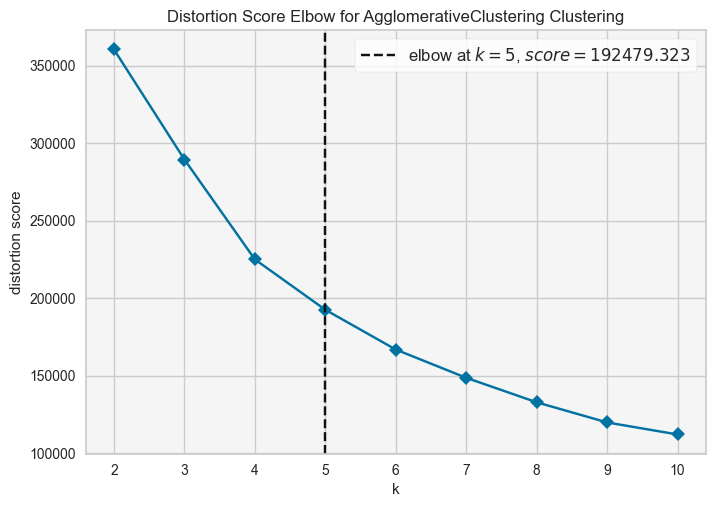

<Axes: title={'center': 'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [25]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(
    AgglomerativeClustering(),
    k=10,
    locate_elbow=True,
    timings=False
)

# Set a different background color (e.g., light gray)
Elbow_M.ax.set_facecolor("#F5F5F5")

Elbow_M.fit(train_pca)
Elbow_M.show()


In [ ]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(
    AgglomerativeClustering(),
    k=10,
    locate_elbow=True,
    timings=False
)

# Set a different background color (e.g., light gray)
Elbow_M.ax.set_facecolor("#F5F5F5")

Elbow_M.fit(val_pca)
Elbow_M.show()


Elbow Method to determine the number of clusters to be formed:


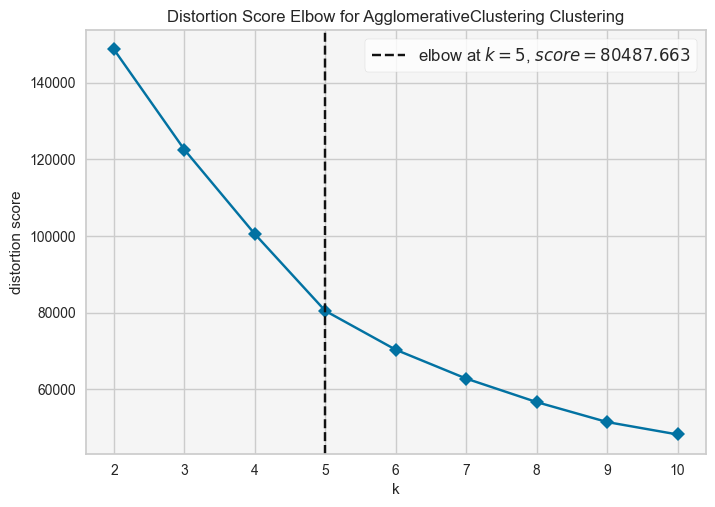

<Axes: title={'center': 'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [26]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(
    AgglomerativeClustering(),
    k=10,
    locate_elbow=True,
    timings=False
)

# Set a different background color (e.g., light gray)
Elbow_M.ax.set_facecolor("#F5F5F5")

Elbow_M.fit(test_pca)
Elbow_M.show()


In [29]:
train_cluster = tag_cluster(train_pca, train_df_encoded, 5)

In [32]:
col_to_use

['CreditScore',
 'OriginalDTI',
 'OriginalLTV',
 'OriginalCLTV',
 'OriginalInterestRate',
 'NumberOfBorrowers',
 'LoanPurpose',
 'PropertyState',
 'PropertyType',
 'Channel',
 'CompositeRiskScore',
 'avg_repayment_ratio',
 'std_repayment_ratio',
 'pct_months_late',
 'repayment_trend_slope',
 'DebtServiceRatio',
 'LoanAge',
 'TimeToMaturity',
 '0_CurrentActualUPB',
 '1_CurrentActualUPB',
 '2_CurrentActualUPB',
 '3_CurrentActualUPB',
 '4_CurrentActualUPB',
 '5_CurrentActualUPB',
 '6_CurrentActualUPB',
 '7_CurrentActualUPB',
 '8_CurrentActualUPB',
 '9_CurrentActualUPB',
 '10_CurrentActualUPB',
 '11_CurrentActualUPB',
 '12_CurrentActualUPB',
 '13_CurrentActualUPB']

In [46]:
train_cluster.Clusters.value_counts()

Clusters
4    8406
2    8130
1    7199
0    5653
3    1108
Name: count, dtype: int64

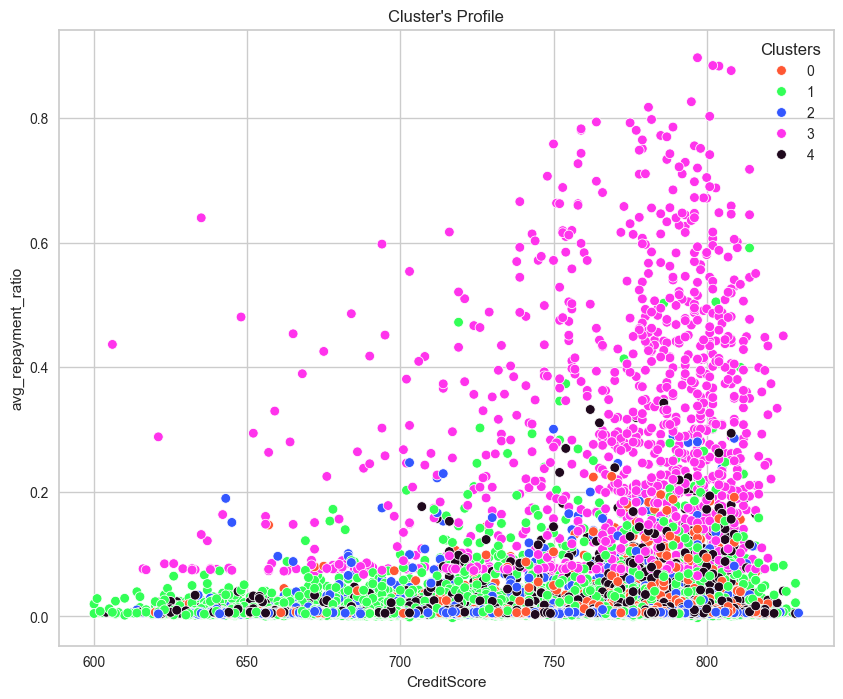

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a bright color palette
bright_palette = ["#FF5733", "#33FF57", "#3357FF", "#FF33EC", "#1F091D"]

# Create a scatterplot
plt.figure(figsize=(10, 8))
scatterplot = sns.scatterplot(data=train_cluster, x="CreditScore", y="avg_repayment_ratio", hue="Clusters", palette=bright_palette)

# Set the title
scatterplot.set_title("Cluster's Profile")

# Show the legend
plt.legend(title="Clusters")

# Show the plot
plt.show()


In [30]:
train_cluster

,target,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,...,HighRiskCredit,HighLTV,HighDTI,HighInterestRate,CompositeRiskScore,avg_repayment_ratio,std_repayment_ratio,pct_months_late,repayment_trend_slope,Clusters
0,0,747,2024-03-01,0,2054-02-01,0.0,0,1,1,67,...,0,0,0,1,1,0.003842,0.004126,0.428571,0.000917,1
1,0,659,2024-03-01,0,2054-02-01,0.0,0,1,1,68,...,0,0,0,1,1,0.005088,0.003236,0.357143,0.000754,2
2,0,775,2024-03-01,0,2054-02-01,46540.0,0,2,0,70,...,0,0,0,1,1,0.006235,0.004532,0.357143,0.001038,1
3,0,815,2024-03-01,1,2054-02-01,0.0,25,1,1,88,...,0,1,1,1,3,0.013596,0.007649,0.500000,0.001138,1
4,0,772,2024-03-01,0,2054-02-01,10900.0,0,1,1,69,...,0,0,0,1,1,0.005180,0.003541,0.500000,0.000763,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30499,0,709,2024-03-01,0,2054-02-01,29340.0,0,1,0,80,...,0,0,0,1,1,0.005987,0.002555,0.428571,0.000572,2
30500,0,782,2024-03-01,0,2054-02-01,31084.0,0,1,1,28,...,0,0,1,0,1,0.006570,0.004208,0.285714,0.000995,4
30501,0,669,2024-03-01,1,2054-02-01,0.0,0,1,1,80,...,0,0,0,0,0,0.004213,0.004553,0.428571,0.001014,1
30502,0,741,2024-03-01,0,2054-02-01,40900.0,30,1,1,95,...,0,1,0,0,1,0.007617,0.004347,0.357143,0.001024,0


In [ ]:
val_cluster = tag_cluster(val_pca, val_df_encoded, 5)

In [ ]:
test_cluster = tag_cluster(test_pca, test_df_encoded, 5)